In [1]:
!pip install lifelines

In [2]:
import sys
!conda install --yes --prefix {sys.prefix} scikit-learn

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.7.0

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines import WeibullAFTFitter



In [4]:
import sys
sys.path.append('/Users/ranjeetamashal/survival-churn-analysis')

from src.preprocessing import load_and_prepare, get_survival_format

df = load_and_prepare('../data/telco_churn.csv')
X, durations, events = get_survival_format(df)

print(f"Dataset shape: {df.shape}")
print(f"Total customers: {len(durations)}")
print(f"Churned (events): {events.sum()} ({events.mean()*100:.1f}%)")
print(f"Censored (still active): {(1-events).sum()} ({(1-events).mean()*100:.1f}%)")
print(f"Duration range: {durations.min()} to {durations.max()} months")
print("\nFirst 5 rows:")
df.head()

Dataset shape: (7043, 20)
Total customers: 7043
Churned (events): 1869 (26.5%)
Censored (still active): 5174 (73.5%)
Duration range: 0 to 72 months

First 5 rows:


,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,duration,event
0,0,0,1,0,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,1,0
1,1,0,0,0,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,34,0
2,1,0,0,0,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,2,1
3,1,0,0,0,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,45,0
4,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,2,1


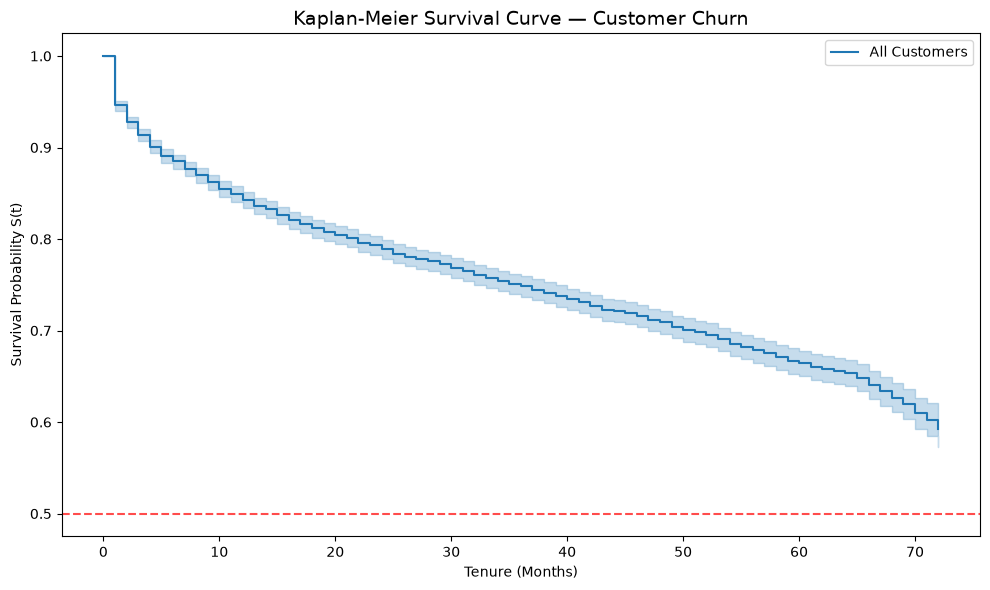

Median survival time: >72 months (fewer than 50% of customers churned)
→ The majority of customers remain active throughout the observation window


In [5]:
from src.kaplan_meier import plot_overall_km

kmf = plot_overall_km(durations, events, save_path='../outputs/km_overall.png')

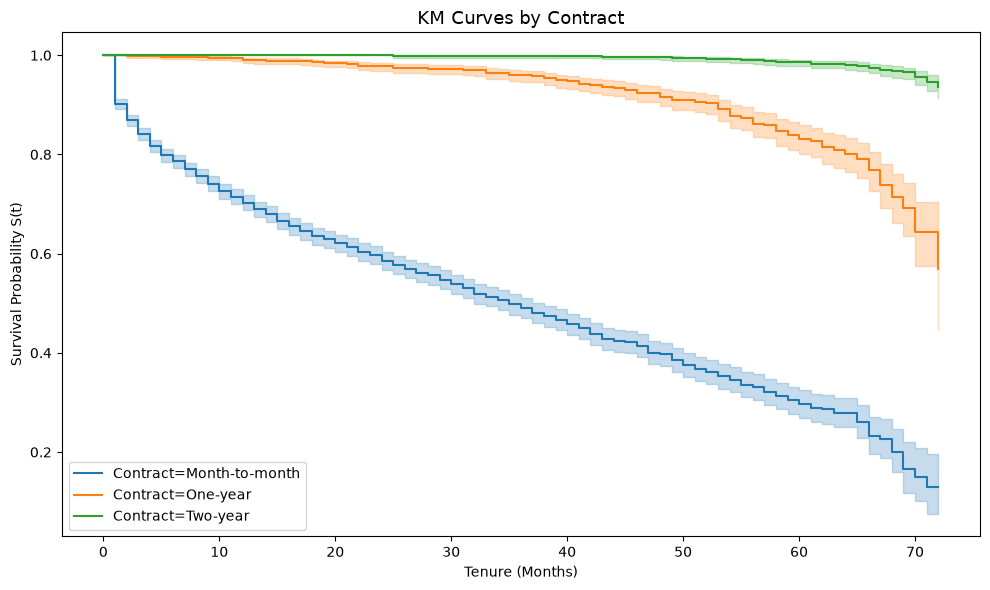

In [7]:
# Decode contract labels for readable legend
df['Contract'] = df['Contract'].map({0: 'Month-to-month', 
                                      1: 'One-year', 
                                      2: 'Two-year'})

plot_km_by_group(df, durations, events,
                 group_col='Contract',
                 save_path='../outputs/km_by_contract.png')

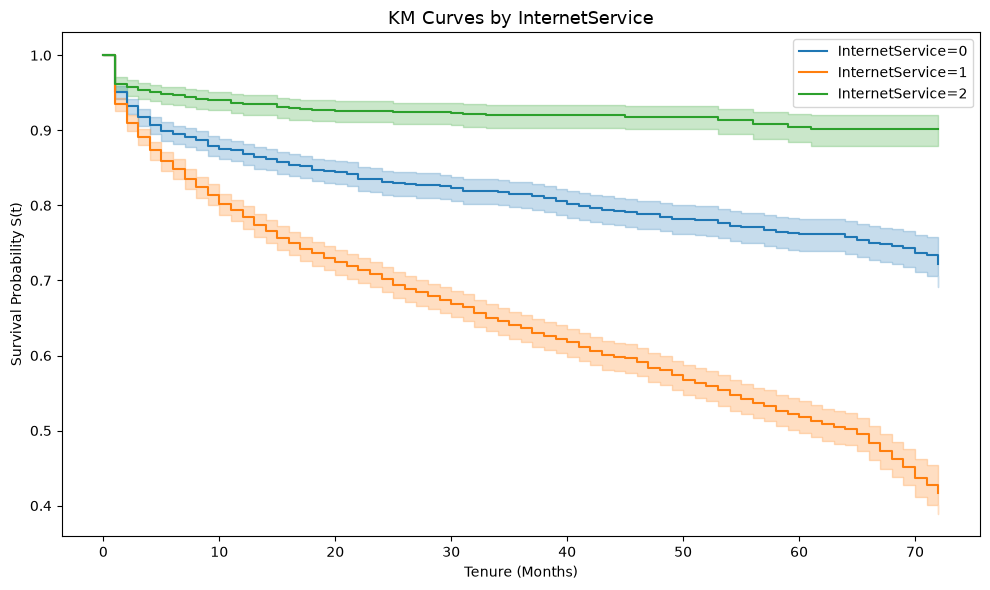

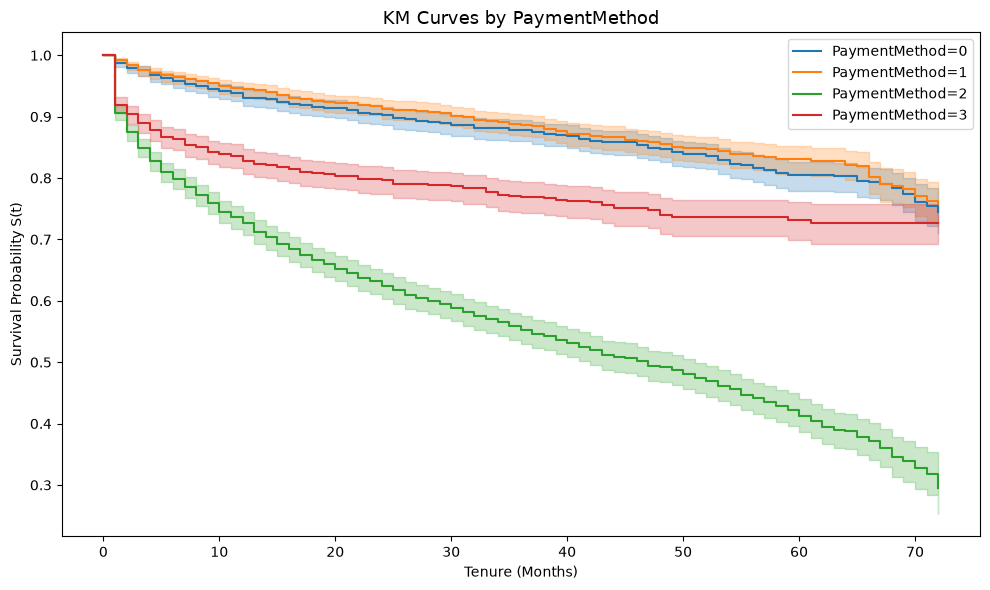

In [8]:
plot_km_by_group(df, durations, events,
                 group_col='InternetService',
                 save_path='../outputs/km_by_internet.png')

plot_km_by_group(df, durations, events,
                 group_col='PaymentMethod',
                 save_path='../outputs/km_by_payment.png')

In [11]:
from src.preprocessing import load_and_prepare, get_survival_format

# Reload fresh numeric data for Cox model
cox_df = load_and_prepare('../data/telco_churn.csv')

from src.cox_model import (fit_cox_model, plot_hazard_ratios,
                            get_c_index, check_proportional_hazards,
                            predict_survival_for_segments)

cph = fit_cox_model(cox_df)

=== Cox PH Model Summary ===


<lifelines.CoxPHFitter: fitted with 7043 total observations, 5174 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 7043
number of events observed = 1869
   partial log-likelihood = -13999.52
         time fit was run = 2026-08-15 14:52:03 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                         
gender           -0.04      0.96      0.04           -0.12            0.04                0.89                1.04
SeniorCitizen     0.10      1.10      0.05            0.00            0.19                1.00                1.21
Partner          -0.30      0.74      0.04           -0.38           -0.21                0.68                0.81
Dependents       -0.19      0.83      0.05           -0.29           -0.09                0.75                0.91
PhoneService      0.05      1.06      0.07           -0.09            0.20                0.91                1.22
MultipleLines    -0.07      0.94      0.02           -0.11           -0.02                0.90                0.98
InternetService  -0.02      0.98      0.03           -0.09            0.04                0.92                1.04
OnlineSecurity   -0.29      0.75      0.03           -0.34           -0.24                0.71                0.79
OnlineBackup     -0.21      0.81      0.02           -0.25           -0.16                0.78                0.85
DeviceProtection -0.14      0.87      0.02           -0.18           -0.09                0.83                0.91
TechSupport      -0.24      0.79      0.03           -0.29           -0.19                0.75                0.83
StreamingTV      -0.01      0.99      0.02           -0.06            0.03                0.94                1.03
StreamingMovies  -0.03      0.97      0.02           -0.07            0.02                0.93                1.02
Contract         -0.72      0.49      0.03           -0.78           -0.65                0.46                0.52
PaperlessBilling  0.25      1.29      0.04            0.17            0.34                1.18                1.41
PaymentMethod     0.17      1.18      0.02            0.13            0.21                1.13                1.23
MonthlyCharges    0.01      1.01      0.00            0.01            0.01                1.01                1.01
TotalCharges     -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00

                  cmp to      z      p  -log2(p)
covariate                                       
gender              0.00  -0.99   0.32      1.63
SeniorCitizen       0.00   1.96   0.05      4.33
Partner             0.00  -6.92 <0.005     37.72
Dependents          0.00  -3.71 <0.005     12.21
PhoneService        0.00   0.73   0.46      1.11
MultipleLines       0.00  -2.97 <0.005      8.41
InternetService     0.00  -0.75   0.46      1.14
OnlineSecurity      0.00 -11.21 <0.005     94.41
OnlineBackup        0.00  -9.02 <0.005     62.17
DeviceProtection    0.00  -5.95 <0.005     28.47
TechSupport         0.00  -9.21 <0.005     64.75
StreamingTV         0.00  -0.56   0.57      0.80
StreamingMovies     0.00  -1.20   0.23      2.11
Contract            0.00 -21.84 <0.005    348.83
PaperlessBilling    0.00   5.71 <0.005     26.44
PaymentMethod       0.00   8.10 <0.005     50.64
MonthlyCharges      0.00  13.38 <0.005    133.27
TotalCharges        0.00 -25.91 <0.005    489.46
---
Concordance = 0.91
Partial AIC = 28035.03
log-likelihood ratio test = 3307.05 on 18 df
-log2(p) of ll-ratio test = inf

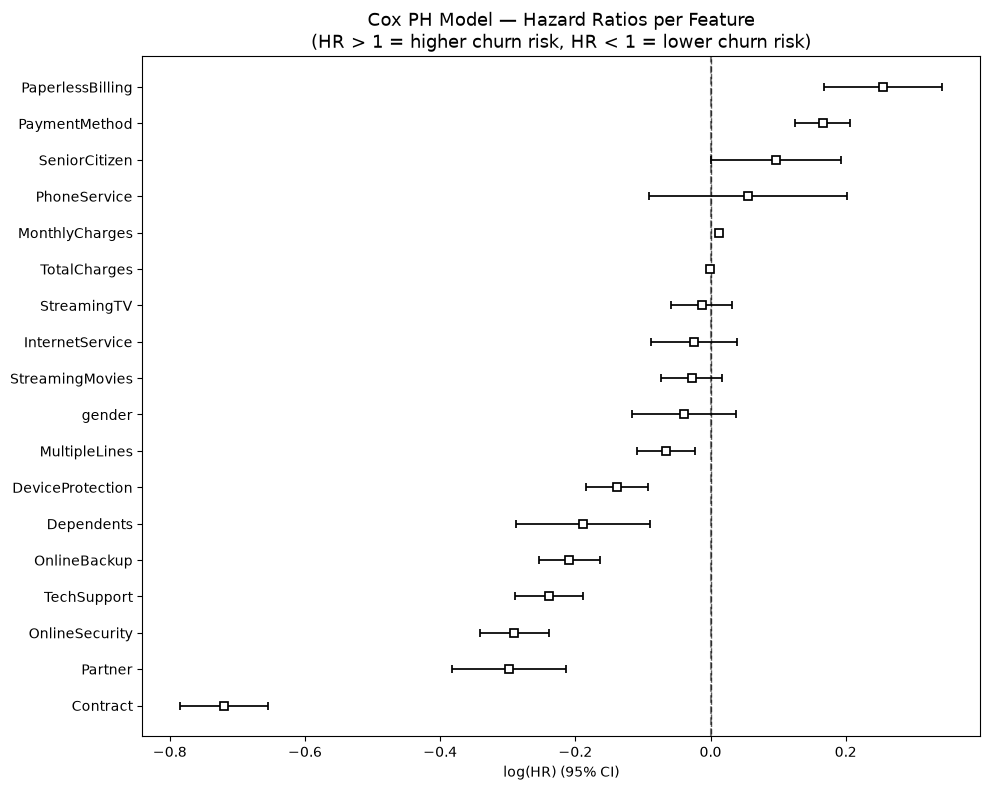

In [12]:
# Hazard ratio plot
plot_hazard_ratios(cph, save_path='../outputs/hazard_ratios.png')

In [13]:
# C-index
c_index = get_c_index(cph)


C-index (Concordance Index): 0.9059
Interpretation: model correctly orders 90.6% of customer pairs by churn risk


In [14]:
# Proportional hazards assumption test
check_proportional_hazards(cph, cox_df)


=== Proportional Hazards Assumption Test ===
                  test_statistic             p   -log2(p)
Contract               16.313579  5.367791e-05  14.185312
Dependents              0.002290  9.618290e-01   0.056148
DeviceProtection        3.164998  7.523253e-02   3.732500
InternetService         2.549805  1.103079e-01   3.180392
MonthlyCharges         49.500716  1.982993e-12  38.875457
MultipleLines          15.550733  8.032051e-05  13.603872
OnlineBackup            3.838858  5.007762e-02   4.319690
OnlineSecurity          1.810391  1.784613e-01   2.486317
PaperlessBilling        1.373693  2.411783e-01   2.051828
Partner                 3.459896  6.287427e-02   3.991387
PaymentMethod           3.066688  7.991212e-02   3.645442
PhoneService            1.912349  1.667025e-01   2.584652
SeniorCitizen           0.159631  6.894963e-01   0.536385
StreamingMovies         9.230207  2.380547e-03   8.714491
StreamingTV            11.080066  8.726070e-04  10.162380
TechSupport             3.

<lifelines.StatisticalResult: proportional_hazard_test>
    time_transform = rank
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 7043 total observations, 5174 right-censored observations>
         test_name = proportional_hazard_test

---
                  test_statistic      p  -log2(p)
Contract                   16.31 <0.005     14.19
Dependents                  0.00   0.96      0.06
DeviceProtection            3.16   0.08      3.73
InternetService             2.55   0.11      3.18
MonthlyCharges             49.50 <0.005     38.88
MultipleLines              15.55 <0.005     13.60
OnlineBackup                3.84   0.05      4.32
OnlineSecurity              1.81   0.18      2.49
PaperlessBilling            1.37   0.24      2.05
Partner                     3.46   0.06      3.99
PaymentMethod               3.07   0.08      3.65
PhoneService                1.91   0.17      2.58
SeniorCitizen               0.16   0.69      0.54
StreamingMovies             9.23 <0.005      8.71
StreamingTV                11.08 <0.005     10.16
TechSupport                 3.02   0.08      3.61
TotalCharges                8.16 <0.005      7.87
gender                      0.33   0.56      0.83

In [17]:
cox_df['duration'] = cox_df['duration'].clip(lower=0.5)

from src.aft_model import fit_aft_model, compare_cox_vs_aft

aft = fit_aft_model(cox_df)
compare_cox_vs_aft(c_index, aft.concordance_index_)

=== Weibull AFT Model Summary ===


<lifelines.WeibullAFTFitter: fitted with 7043 total observations, 5174 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
   number of observations = 7043
number of events observed = 1869
           log-likelihood = -8903.47
         time fit was run = 2026-08-15 14:55:04 UTC

---
                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                         
lambda_ Contract          0.58      1.78      0.03            0.52            0.64                1.68                1.89
        Dependents        0.16      1.17      0.04            0.07            0.24                1.07                1.27
        DeviceProtection  0.10      1.11      0.02            0.07            0.14                1.07                1.15
        InternetService   0.01      1.01      0.03           -0.05            0.07                0.96                1.07
        MonthlyCharges   -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
        MultipleLines     0.07      1.07      0.02            0.03            0.10                1.03                1.11
        OnlineBackup      0.16      1.17      0.02            0.12            0.19                1.13                1.21
        OnlineSecurity    0.23      1.26      0.02            0.19            0.28                1.21                1.32
        PaperlessBilling -0.20      0.82      0.04           -0.27           -0.12                0.76                0.88
        Partner           0.23      1.26      0.04            0.16            0.30                1.17                1.35
        PaymentMethod    -0.14      0.87      0.02           -0.18           -0.11                0.84                0.90
        PhoneService     -0.03      0.97      0.06           -0.16            0.09                0.85                1.10
        SeniorCitizen    -0.05      0.95      0.04           -0.13            0.02                0.88                1.02
        StreamingMovies   0.03      1.03      0.02           -0.01            0.06                0.99                1.07
        StreamingTV       0.01      1.01      0.02           -0.03            0.05                0.97                1.05
        TechSupport       0.19      1.21      0.02            0.15            0.23                1.16                1.26
        TotalCharges      0.00      1.00      0.00            0.00            0.00                1.00                1.00
        gender            0.03      1.03      0.03           -0.03            0.10                0.97                1.10
        Intercept         3.58     35.97      0.08            3.42            3.74               30.68               42.17
rho_    Intercept         0.26      1.30      0.02            0.22            0.29                1.25                1.34

                          cmp to      z      p  -log2(p)
param   covariate                                       
lambda_ Contract            0.00  19.68 <0.005    284.00
        Dependents          0.00   3.62 <0.005     11.72
        DeviceProtection    0.00   5.48 <0.005     24.53
        InternetService     0.00   0.37   0.71      0.49
        MonthlyCharges      0.00 -15.59 <0.005    179.59
        MultipleLines       0.00   3.68 <0.005     12.05
        OnlineBackup        0.00   8.29 <0.005     52.98
        OnlineSecurity      0.00  10.61 <0.005     84.99
        PaperlessBilling    0.00  -5.23 <0.005     22.48
        Partner             0.00   6.47 <0.005     33.29
        PaymentMethod       0.00  -8.42 <0.005     54.56
        PhoneService        0.00  -0.52   0.60      0.74
        SeniorCitizen       0.00  -1.35   0.18      2.51
        StreamingMovies     0.00   1.41   0.16      2.67
        Stream


AFT C-index: 0.9138

=== Model Comparison ===
Cox PH C-index:      0.9059
Weibull AFT C-index: 0.9138
Better model: Weibull AFT


In [18]:
from src.aft_model import fit_aft_model, compare_cox_vs_aft

aft = fit_aft_model(cox_df)
compare_cox_vs_aft(c_index, aft.concordance_index_)

=== Weibull AFT Model Summary ===


<lifelines.WeibullAFTFitter: fitted with 7043 total observations, 5174 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
   number of observations = 7043
number of events observed = 1869
           log-likelihood = -8903.47
         time fit was run = 2026-08-15 14:55:09 UTC

---
                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                         
lambda_ Contract          0.58      1.78      0.03            0.52            0.64                1.68                1.89
        Dependents        0.16      1.17      0.04            0.07            0.24                1.07                1.27
        DeviceProtection  0.10      1.11      0.02            0.07            0.14                1.07                1.15
        InternetService   0.01      1.01      0.03           -0.05            0.07                0.96                1.07
        MonthlyCharges   -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
        MultipleLines     0.07      1.07      0.02            0.03            0.10                1.03                1.11
        OnlineBackup      0.16      1.17      0.02            0.12            0.19                1.13                1.21
        OnlineSecurity    0.23      1.26      0.02            0.19            0.28                1.21                1.32
        PaperlessBilling -0.20      0.82      0.04           -0.27           -0.12                0.76                0.88
        Partner           0.23      1.26      0.04            0.16            0.30                1.17                1.35
        PaymentMethod    -0.14      0.87      0.02           -0.18           -0.11                0.84                0.90
        PhoneService     -0.03      0.97      0.06           -0.16            0.09                0.85                1.10
        SeniorCitizen    -0.05      0.95      0.04           -0.13            0.02                0.88                1.02
        StreamingMovies   0.03      1.03      0.02           -0.01            0.06                0.99                1.07
        StreamingTV       0.01      1.01      0.02           -0.03            0.05                0.97                1.05
        TechSupport       0.19      1.21      0.02            0.15            0.23                1.16                1.26
        TotalCharges      0.00      1.00      0.00            0.00            0.00                1.00                1.00
        gender            0.03      1.03      0.03           -0.03            0.10                0.97                1.10
        Intercept         3.58     35.97      0.08            3.42            3.74               30.68               42.17
rho_    Intercept         0.26      1.30      0.02            0.22            0.29                1.25                1.34

                          cmp to      z      p  -log2(p)
param   covariate                                       
lambda_ Contract            0.00  19.68 <0.005    284.00
        Dependents          0.00   3.62 <0.005     11.72
        DeviceProtection    0.00   5.48 <0.005     24.53
        InternetService     0.00   0.37   0.71      0.49
        MonthlyCharges      0.00 -15.59 <0.005    179.59
        MultipleLines       0.00   3.68 <0.005     12.05
        OnlineBackup        0.00   8.29 <0.005     52.98
        OnlineSecurity      0.00  10.61 <0.005     84.99
        PaperlessBilling    0.00  -5.23 <0.005     22.48
        Partner             0.00   6.47 <0.005     33.29
        PaymentMethod       0.00  -8.42 <0.005     54.56
        PhoneService        0.00  -0.52   0.60      0.74
        SeniorCitizen       0.00  -1.35   0.18      2.51
        StreamingMovies     0.00   1.41   0.16      2.67
        Stream


AFT C-index: 0.9138

=== Model Comparison ===
Cox PH C-index:      0.9059
Weibull AFT C-index: 0.9138
Better model: Weibull AFT


In [19]:
from src.preprocessing import get_survival_format
X, durations, events = get_survival_format(cox_df)
predict_survival_for_segments(cph, X, durations, events)


=== Predicted Survival Probabilities ===
  P(survive>6mo): 0.880
  P(survive>12mo): 0.823
  P(survive>24mo): 0.735
  P(survive>36mo): 0.656
  P(survive>48mo): 0.567


{'P(survive>6mo)': np.float64(0.8796294577788872),
 'P(survive>12mo)': np.float64(0.8232735983619476),
 'P(survive>24mo)': np.float64(0.7351089420978307),
 'P(survive>36mo)': np.float64(0.6555100160715531),
 'P(survive>48mo)': np.float64(0.5674529366894318)}